## Peak performance comparison between Multi-core Scan and `torch.clone` copy operator

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2.
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["s", "^", "v", "<", ">", "o", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [3]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [4]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [5]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy"
add_stats_siso(df_copy, 2)


df_baseline = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_{dtype}.csv")
df_baseline["S"] = "PyTorch"
add_stats_siso(df_baseline, 4)


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_{tile}_{dtype}.csv")
    df_tmp["S"] = f"s={tile}"
    df_tiled = pd.concat([df_tiled, df_tmp])

add_stats_siso(df_tiled, 4)

df = pd.concat([df_copy, df_baseline, df_tiled])

## Paper plots

/tmp/ipykernel_1552083/1400779086.py:9: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)


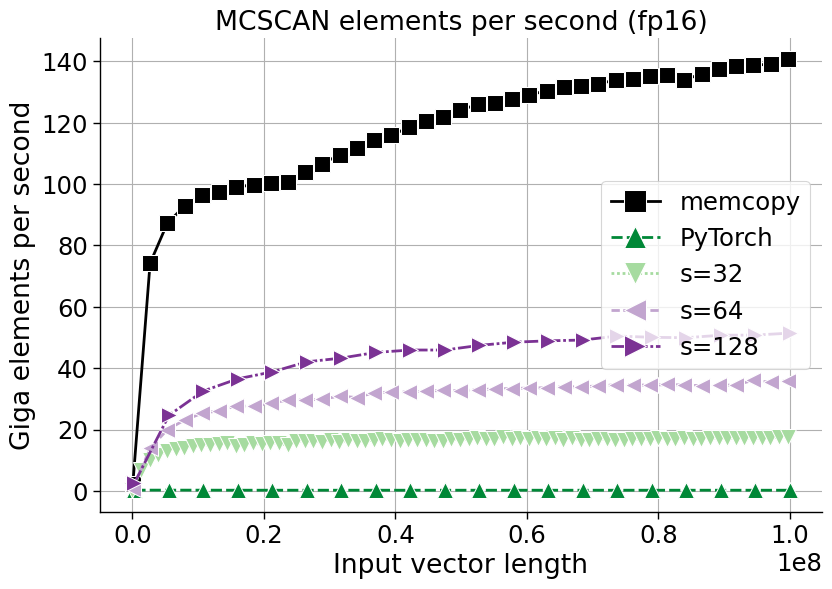

<Figure size 870x627 with 0 Axes>

In [ ]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"MCSCAN elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

/tmp/ipykernel_1552083/290925490.py:9: UserWarning: The markers list has more values (7) than needed (5), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)


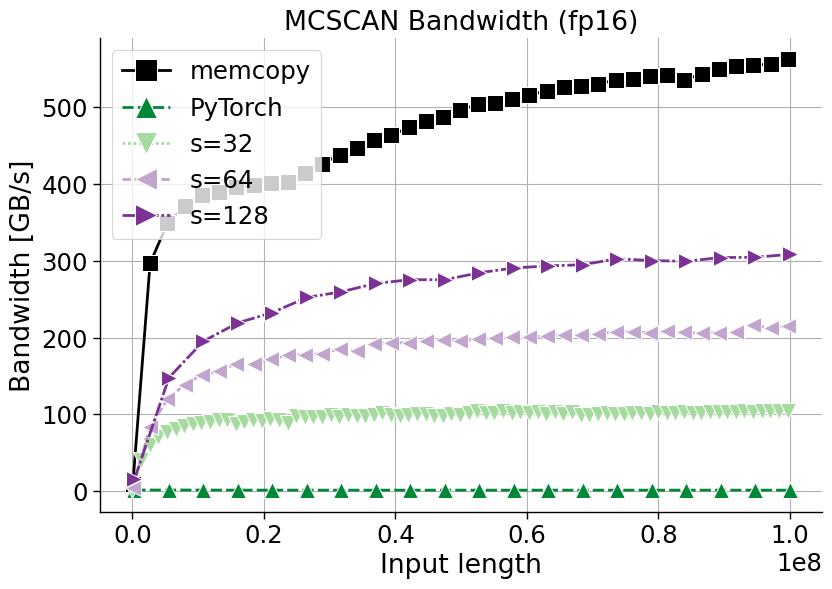

<Figure size 870x627 with 0 Axes>

In [ ]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"MCSCAN Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_bw_{dtype}.png")
plt.show()
plt.clf()


In [15]:
df.head(100)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,copy_fp16,fp16,81920,NaN,81920,36.19,memcopy,2,327680,2.263609,9.054435
1,copy_fp16,fp16,2703360,NaN,2703360,36.16,memcopy,2,10813440,74.761062,299.044248
2,copy_fp16,fp16,5324800,NaN,5324800,56.55,memcopy,2,21299200,94.160920,376.643678
3,copy_fp16,fp16,7946240,NaN,7946240,81.44,memcopy,2,31784960,97.571709,390.286837
4,copy_fp16,fp16,10567680,NaN,10567680,109.34,memcopy,2,42270720,96.649716,386.598866
...,...,...,...,...,...,...,...,...,...,...,...
36,mcscan_32_fp16,fp16,47206400,NaN,47206400,2903.21,s=32,2,283238400,16.260071,97.560424
37,mcscan_32_fp16,fp16,48517120,NaN,48517120,2886.46,s=32,2,291102720,16.808520,100.851119
38,mcscan_32_fp16,fp16,49827840,NaN,49827840,2994.27,s=32,2,298967040,16.641064,99.846387
39,mcscan_32_fp16,fp16,51138560,NaN,51138560,3005.84,s=32,2,306831360,17.013068,102.078407


In [16]:
max_size = df["size"].max()
df[df["size"] >= 99 * 1e6].head(20)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
38,copy_fp16,fp16,99696640,NaN,99696640,709.22,memcopy,2,398786560,140.572234,562.288937
19,scan_fp16,fp16,99942400,NaN,99942400,447608.86,PyTorch,2,599654400,0.223281,1.339684
76,mcscan_32_fp16,fp16,99635200,NaN,99635200,5699.55,s=32,2,597811200,17.481240,104.887438
38,mcscan_64_fp16,fp16,99696640,NaN,99696640,2775.79,s=64,2,598179840,35.916492,215.498953
19,mcscan_128_fp16,fp16,99942400,NaN,99942400,1962.66,s=128,2,599654400,50.921912,305.531473
